In [1]:
import os
import numpy as np
import pandas as pd
import cv2

import splitfolders
import h5py
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
import seaborn as sns
from PIL import Image
import imutils 
# from openslide import OpenSlide

In [5]:
def crop_image(image_to_crop_path, cropped_images_folder):
    # img = cv2.imread('C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/image Sets/val/glioma/G1391.jpg')
    # img = cv2.imread('C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/image Sets/test/glioma/G260.jpg') # The algo really struggled with these 2 
    # img = cv2.imread('C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/image Sets/train/pituitary_tumor/P477.jpg') # The algo really struggled with these 2 
    print("dsvyg: ", image_to_crop_path)
    image_to_crop = cv2.imread(image_to_crop_path)
    img_size = image_to_crop.shape
    print("img_size: ", img_size)
    image_to_crop = cv2.resize(
                image_to_crop,
                dsize=(256,256),
                interpolation=cv2.INTER_CUBIC
            )
    gray = cv2.cvtColor(image_to_crop, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # add contour on the image
    img_cnt = cv2.drawContours(image_to_crop.copy(), [c], -1, (0, 255, 255), 4)

    # add extreme points
    img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
    img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
    img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
    img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

    # crop
    ADD_PIXELS = 0
    Cropped_image = image_to_crop[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

    current_image_name = image_to_crop_path.rsplit('/', 1)[1]
    # print("current_image_name: ", current_image_name)
    Cropped_image_name = current_image_name.rsplit('.')[0] + '_cropped' + "."+ current_image_name.split('.')[1]
    # print("Cropped_image_name: ", Cropped_image_name)
    print(
        f"Writing the Cropped image {Cropped_image_name} to {cropped_images_folder}... "
    )
    Cropped_image_path = f"{cropped_images_folder}/{Cropped_image_name}"
    print("Cropped_image_path: ", Cropped_image_path)
    plt.imshow(Cropped_image)
    saved_cropped_image = cv2.imwrite(Cropped_image_path, Cropped_image)

Children_directories:  ['glioma', 'meningioma', 'pituitary_tumor']
specific_class_folder:  C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Training/glioma
dsvyg:  C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Training/glioma/G1.jpg
img_size:  (1617, 1616, 3)
Writing the Cropped image G1_cropped.jpg to C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Cropped_images/glioma_cropped... 
Cropped_image_path:  C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Cropped_images/glioma_cropped/G1_cropped.jpg
dsvyg:  C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Training/glioma/G10.jpg
img_size:  (1617, 1616, 3)
Writing the Cropped image G10_cropped.jpg to C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Cropped_images/glioma_cropped... 
Cropped_image_path:

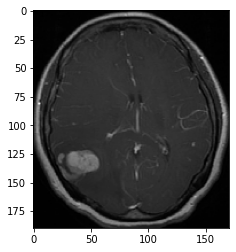

In [6]:
Root = "C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/"
Classes = "C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Training/"
Children_directories = next(os.walk(Classes))[1]

print("Children_directories: ", Children_directories)
for i in range(len(Children_directories)):
    if i == 0:    
        specific_class_folder = os.path.join(Classes,Children_directories[i])
        print("specific_class_folder: ", specific_class_folder)
        
        # Create a new specific_class_folder for the cropped images
        cropped_images_folder = Classes.replace('Training', 'Cropped_images') + Children_directories[i] + '_cropped'
        # print("cropped_images_folder: ", cropped_images_folder)
        
        if not os.path.exists(cropped_images_folder):
            os.makedirs(cropped_images_folder)
        for root, dirs, files in os.walk(specific_class_folder):
            for file in range(len(files)):
                image_path =root+ '/' + files[file]
                # print("image_path: ", image_path)
                crop_image(image_path, cropped_images_folder)
                if file == 1:
                    break
    else:
        break

In [ ]:
# plt.figure(figsize=(15,6))
# plt.subplot(141)
# plt.imshow(image_to_crop)
# plt.xticks([])
# plt.yticks([])
# plt.title('Step 1. Get the original image')
# plt.subplot(142)
# plt.imshow(img_cnt)
# plt.xticks([])
# plt.yticks([])
# plt.title('Step 2. Find the biggest contour')
# plt.subplot(143)
# plt.imshow(img_pnt)
# plt.xticks([])
# plt.yticks([])
# plt.title('Step 3. Find the extreme points')
# plt.subplot(144)
# plt.imshow(Cropped_image)
# plt.xticks([])
# plt.yticks([])
# plt.title('Step 4. Crop the image')
# plt.show()

In [3]:
# Input_folder = 'C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/Training'
# Output = 'C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/image Sets'
# splitfolders.ratio(Input_folder, output=Output,
#     seed=1337, ratio=(.7, .15, .15), group_prefix=None, move=False) 

Copying files: 3064 files [00:21, 144.97 files/s]


In [ ]:
# def crop_imgs(set_name, add_pixels_value=0):
#     """
#     Finds the extreme points on the image and crops the rectangular out of them
#     """
#     set_new = []
#     for img in set_name:
#         gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#         gray = cv2.GaussianBlur(gray, (5, 5), 0)

#         # threshold the image, then perform a series of erosions +
#         # dilations to remove any small regions of noise
#         thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
#         thresh = cv2.erode(thresh, None, iterations=2)
#         thresh = cv2.dilate(thresh, None, iterations=2)

#         # find contours in thresholded image, then grab the largest one
#         cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         cnts = imutils.grab_contours(cnts)
#         c = max(cnts, key=cv2.contourArea)

#         # find the extreme points
#         extLeft = tuple(c[c[:, :, 0].argmin()][0])
#         extRight = tuple(c[c[:, :, 0].argmax()][0])
#         extTop = tuple(c[c[:, :, 1].argmin()][0])
#         extBot = tuple(c[c[:, :, 1].argmax()][0])

#         ADD_PIXELS = add_pixels_value
#         new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
#         set_new.append(new_img)

#     return np.array(set_new)